# PMF, CDF, Joint Distribution
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Shayan Maleki

*SID:* 810102515

The objective of this notebook is to understand the concepts of PMF and CDF and joint distribution.

In [2]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Parameters

In [3]:
num_counters = 1
arrival_rate = 5  # customers per minute
service_rate = 6  # customers per minute
simulation_time = 10000  # minutes

## Simulation

In [4]:
def simulate_queue_system():
    """
    Simulates a queue system with customers arriving at service counters, waiting for service, and being served.

    This function defines the customer behavior and the setup of the simulation environment. It initializes the simulation environment, sets up the service counters, and continuously generates customer arrivals based on specified arrival and service rates. The function runs the simulation until the specified simulation time and returns the recorded wait times, arrival times, and service times of the customers.

    Returns:
        tuple: A tuple containing three lists - wait_times, arrival_times, and service_times, which record the respective times for each customer in the simulation.
    """

    def customer(
        env: simpy.Environment,
        name: str,
        counter: simpy.Resource,
        service_time: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Simulates a customer arriving at a service counter, waiting for service, and then being served.

        Args:
            env (simpy.Environment): The simulation environment.
            name (str): The name of the customer.
            counter (simpy.Resource): The service counter resource.
            service_time (float): The time it takes to serve the customer.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Process: The process of the customer being served.
        """
        arrival_time = env.now
        arrival_times.append(arrival_time)
        with counter.request() as req:
            yield req
            yield env.timeout(service_time)
            service_times.append(service_time)
            wait_time = env.now - arrival_time
            wait_times.append(wait_time)

    def setup(
        env: simpy.Environment,
        num_counters: int,
        arrival_rate: float,
        service_rate: float,
        wait_times: list,
        arrival_times: list,
        service_times: list,
    ):
        """
        Sets up the simulation environment with a specified number of service counters and customer arrival and service rates.

        Args:
            env (simpy.Environment): The simulation environment.
            num_counters (int): The number of service counters available.
            arrival_rate (float): The rate at which customers arrive.
            service_rate (float): The rate at which customers are served.
            wait_times (list): A list to record the wait times of customers.
            arrival_times (list): A list to record the arrival times of customers.
            service_times (list): A list to record the service times of customers.

        Yields:
            simpy.events.Timeout: The timeout event for the next customer arrival.
        """
        counter = simpy.Resource(env, num_counters)
        while True:
            yield env.timeout(np.random.exponential(1 / arrival_rate))
            service_time = np.random.exponential(1 / service_rate)
            env.process(
                customer(
                    env,
                    "Customer",
                    counter,
                    service_time,
                    wait_times,
                    arrival_times,
                    service_times,
                )
            )

    while True:
        env = simpy.Environment()
        wait_times = []
        arrival_times = []
        service_times = []
        env.process(
            setup(
                env,
                num_counters,
                arrival_rate,
                service_rate,
                wait_times,
                arrival_times,
                service_times,
            )
        )
        env.run(until=simulation_time)

        if len(wait_times) == len(arrival_times) == len(service_times):
            return wait_times, arrival_times, service_times
        
wait_times, arrival_times, service_times = simulate_queue_system()

## Plot the RVs Distributions

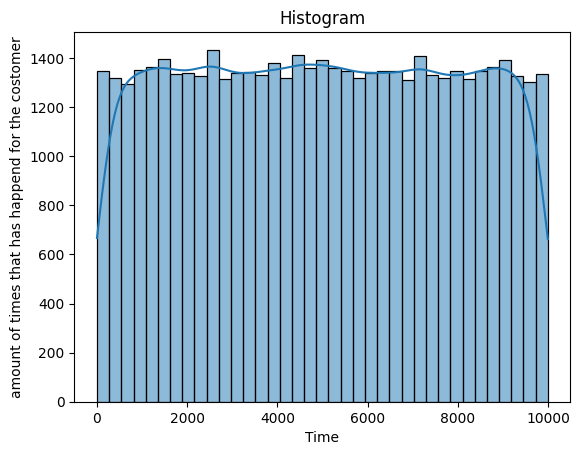

In [54]:
######################  TODO  ########################
# Distribution of Arrival Times
sns.histplot(arrival_times,kde=True) 
plt.title('Histogram')
plt.xlabel('Time') 
plt.ylabel('amount of times that has happend for the costomer') 
plt.show()
######################  TODO  ########################

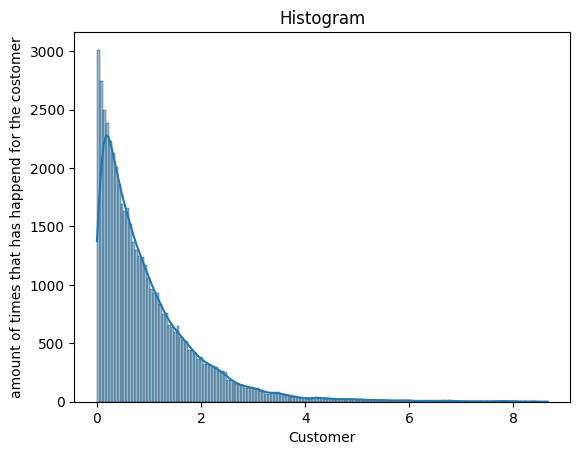

In [55]:
######################  TODO  ########################
# Distribution of Waiting Times
sns.histplot(wait_times,kde=True) 
plt.title('Histogram')
plt.xlabel('Customer') 
plt.ylabel('amount of times that has happend for the costomer') 
plt.show()
######################  TODO  ########################

Text(0, 0.5, 'amount of times that has happend for the costomer')

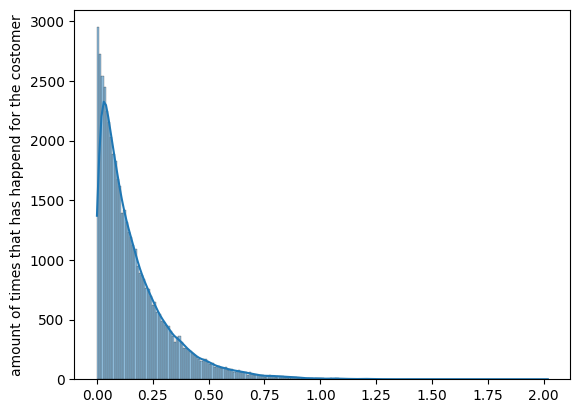

In [56]:
######################  TODO  ########################
# Distribution of Service Times
sns.histplot(service_times,kde=True)
plt.ylabel('amount of times that has happend for the costomer')  
######################  TODO  ########################

    we have implemented the diagrams of waiting times and the others .
    about the kde paramether all i have to say is that it draws a continuous diagram over our histogram diagram.
    as for the distributions the waiting times look like a uniform distribution and the others look like exponential.
    

## Plot the Joint Distributions

**Note:** Use `sns.jointplot` to plot the joint distributions

Text(0.5, 1.0, 'Joint plot of arrival and service times')

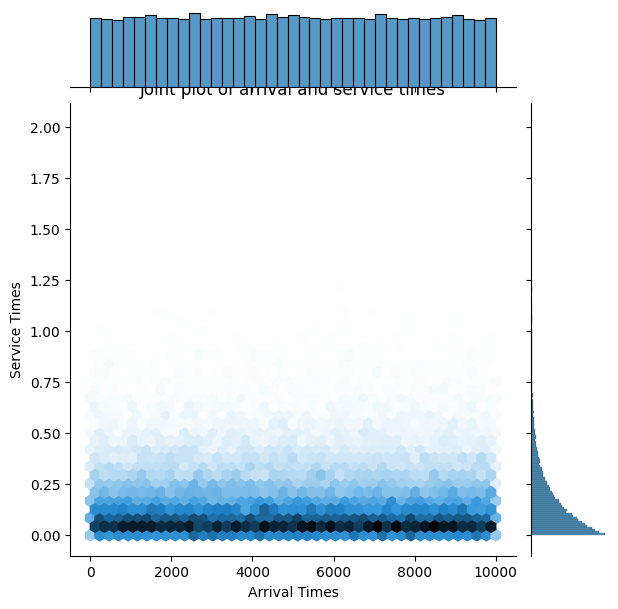

In [41]:
######################  TODO  ########################
# Joint Distribution of Arrival and Service Timess
sns.jointplot(x=arrival_times, y=service_times,kind="hex") 
plt.xlabel('Arrival Times') 
plt.ylabel('Service Times') 
plt.title('Joint plot of arrival and service times')
######################  TODO  ########################

Text(0.5, 1.0, 'Joint plot of arrival and wait times')

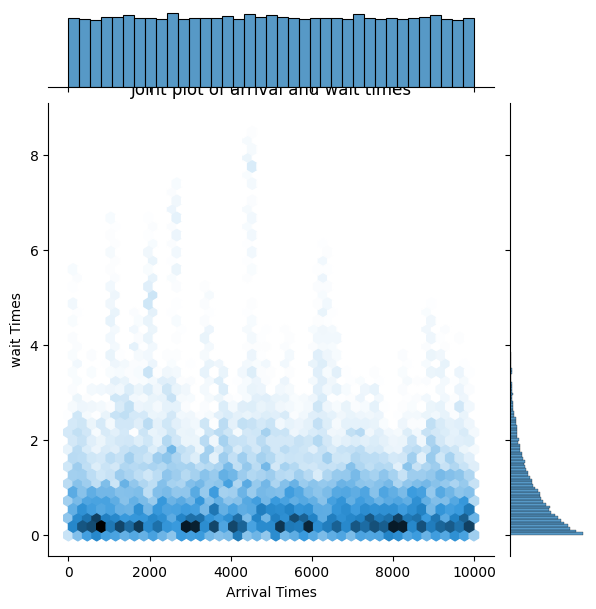

In [42]:
######################  TODO  ########################
# Joint Distribution of Arrival and Wait Times
sns.jointplot(x=arrival_times, y=wait_times,kind="hex") 
plt.xlabel('Arrival Times') 
plt.ylabel('wait Times') 
plt.title('Joint plot of arrival and wait times')
######################  TODO  ########################

## Analysis of Joint Distributions

    according to the diagrams we have drewd we cant gather the dots in a linear order at all so neither one of them are correlated

## Scatter Plot and Correlation

-0.0827395132953161


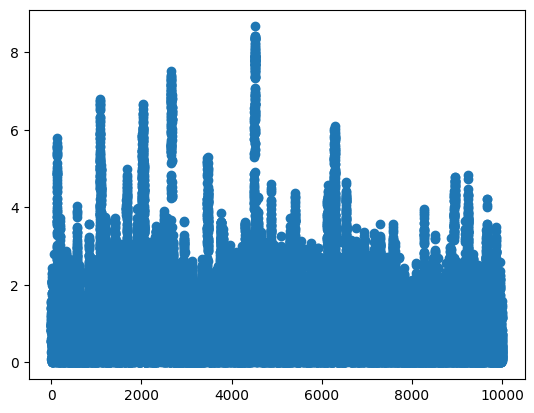

In [73]:
######################  TODO  ########################
# Scatter Plot of Arrival and Service Times
plt.scatter(arrival_times, wait_times)
correlation = np.corrcoef(arrival_times,wait_times)
print(correlation[0, 1])
######################  TODO  ########################

## Calculating `total_times`

<Axes: ylabel='Count'>

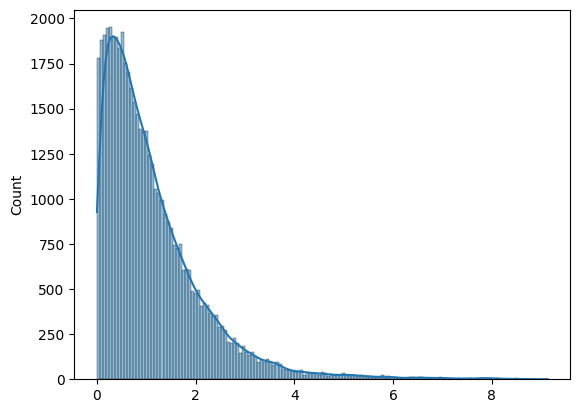

In [78]:
######################  TODO  ########################
# Distribution of Total Time Spent in the System
total_times=np.array(service_times)+np.array(wait_times)
sns.histplot(total_times,kde=True) 
######################  TODO  ########################

    as we have previously observed the two waiting times and service times are both exponential distribution so as we have previously prooved the sum of 2 exp distributions with l as lambda is l^2ze^(-lz) (z is our X+Y).
    so our total time digram would still like an exp distribution.
    

## Conditional Wait Times

Text(0, 0.5, 'amount of times that has happend for the costomer')

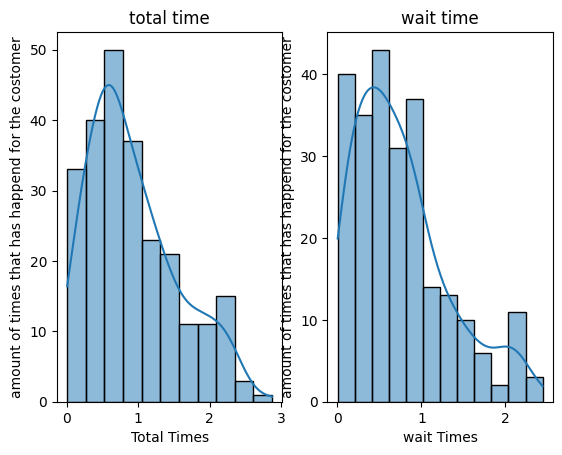

In [79]:
######################  TODO  ########################
# Conditional Distribution of Waiting Times (Arrival Time < 50)
condition =np.array(arrival_times)<50
filteredTotalTimes=total_times[condition]
npWaitTimes=np.array(wait_times)
filteredWaitTimes=npWaitTimes[condition]

plt.subplot(1, 2, 1) 
sns.histplot(filteredTotalTimes,kde=True) 
plt.title('total time') 
plt.xlabel('Total Times') 
plt.ylabel('amount of times that has happend for the costomer')  

plt.subplot(1, 2, 2) 
sns.histplot(filteredWaitTimes,kde=True) 
plt.title('wait time') 
plt.xlabel('wait Times') 
plt.ylabel('amount of times that has happend for the costomer')  
#####################  TODO  ########################